# Experiment 5: Linear Regression through Gradient Descent

This notebook predicts the final mathematics grade (`G3`) from the Student Performance dataset. `G1` and `G2` are excluded because they are earlier-period grades and would leak target-related information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = 'student/student-mat.csv'

## 1. Load data and select features

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Dataset shape: {df.shape}')
print(f'Total missing values: {df.isna().sum().sum()}')

target = 'G3'
X = df.drop(columns=[target, 'G1', 'G2'])
y = df[target]

print(f'Input features: {X.shape[1]}')
print(f'Target: {target}')

Dataset shape: (395, 33)
Total missing values: 0
Input features: 30
Target: G3


## 2. Preprocess and split the data

Numeric values are median-imputed and standardized. Categorical values are mode-imputed and one-hot encoded. The preprocessor is fitted only on the training data.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f'Training shape after preprocessing: {X_train_processed.shape}')
print(f'Testing shape after preprocessing:  {X_test_processed.shape}')

Training shape after preprocessing: (316, 56)
Testing shape after preprocessing:  (79, 56)


## 3. Linear Regression implemented with Gradient Descent

In [4]:
class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.01, n_iterations=3000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            predictions = X @ self.weights + self.bias
            errors = predictions - y
            self.weights -= self.learning_rate * (2 / n_samples) * (X.T @ errors)
            self.bias -= self.learning_rate * 2 * errors.mean()
            self.loss_history.append(np.mean(errors ** 2))
        return self

    def predict(self, X):
        return np.asarray(X, dtype=float) @ self.weights + self.bias

## 4. Compare learning rates and plot convergence

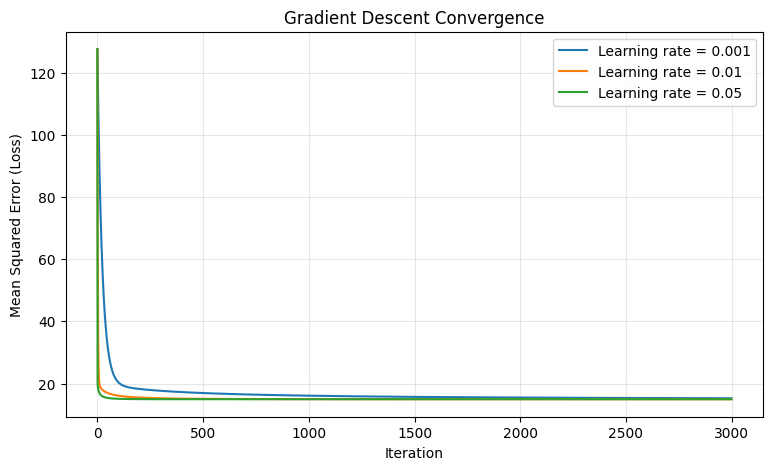

,Learning rate,Initial loss,Final loss
0,0.001,127.6297,15.2477
1,0.010,127.6297,14.9393
2,0.050,127.6297,14.9390


In [5]:
learning_rates = [0.001, 0.01, 0.05]
models = {}

plt.figure(figsize=(9, 5))
for learning_rate in learning_rates:
    model = LinearRegressionGradientDescent(learning_rate=learning_rate, n_iterations=3000)
    model.fit(X_train_processed, y_train)
    models[learning_rate] = model
    plt.plot(model.loss_history, label=f'Learning rate = {learning_rate}')

plt.title('Gradient Descent Convergence')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (Loss)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    'Learning rate': learning_rates,
    'Initial loss': [models[lr].loss_history[0] for lr in learning_rates],
    'Final loss': [models[lr].loss_history[-1] for lr in learning_rates]
}).round(4)

## 5. Evaluate the trained model

The learning rate with the lowest final training loss is selected.

In [6]:
best_learning_rate = min(models, key=lambda lr: models[lr].loss_history[-1])
best_model = models[best_learning_rate]
y_pred = best_model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
display(metrics.round(4))

print(f'Selected learning rate: {best_learning_rate}')
print(f'Final training loss: {best_model.loss_history[-1]:.4f}')

,Metric,Value
0,MAE,3.3953
1,MSE,17.6037
2,RMSE,4.1957
3,R² Score,0.1415


Selected learning rate: 0.05
Final training loss: 14.9390


## 6. Interpretation

The loss curves show whether each learning rate converges: a rapidly decreasing curve that levels off indicates stable convergence, while a slowly declining curve indicates slower learning. The selected rate has the lowest final training loss among those tested. MAE and RMSE express prediction error in grade points; lower values indicate better predictions. The R² score gives the proportion of variation in final grades explained by the selected features, where a larger value indicates stronger predictive performance.